# Fraud Detection – Credit Card Transactions

**Task:** Identify fraudulent credit card transactions using machine learning on a highly imbalanced dataset.

**Dataset:** `creditcard.csv` — 284,807 transactions with 31 columns.

---
### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load & Explore Data |
| 3 | Data Cleaning |
| 4 | EDA & Visualization |
| 5 | Feature Engineering & 80/20 Split |
| 6 | Model Training on Full Dataset (LR, DT, RF) |
| 7 | Model Evaluation & Comparison |

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models — class_weight='balanced' handles imbalance on full data
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


## 2. Load Dataset & Initial Exploration

In [23]:
# Load full dataset — 284,807 rows, may take ~30 seconds
df = pd.read_csv('creditcard.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
# Column types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [25]:
# Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [26]:
# Class distribution — key challenge: severe imbalance
class_counts = df['Class'].value_counts()
fraud_pct = (class_counts[1] / len(df)) * 100

print('Class Distribution:')
print(f'  Legitimate (0): {class_counts[0]:,}')
print(f'  Fraudulent (1): {class_counts[1]:,}')
print(f'  Fraud percentage: {fraud_pct:.4f}%')

Class Distribution:
  Legitimate (0): 284,315
  Fraudulent (1): 492
  Fraud percentage: 0.1727%


## 3. Data Cleaning

In [27]:
# Check for missing values
print('Missing values:', df.isnull().sum().sum())

# Remove duplicate rows
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - df.shape[0]}')
print(f'Clean shape: {df.shape}')

Missing values: 0
Duplicates removed: 1081
Clean shape: (283726, 31)


## 4. EDA & Visualization

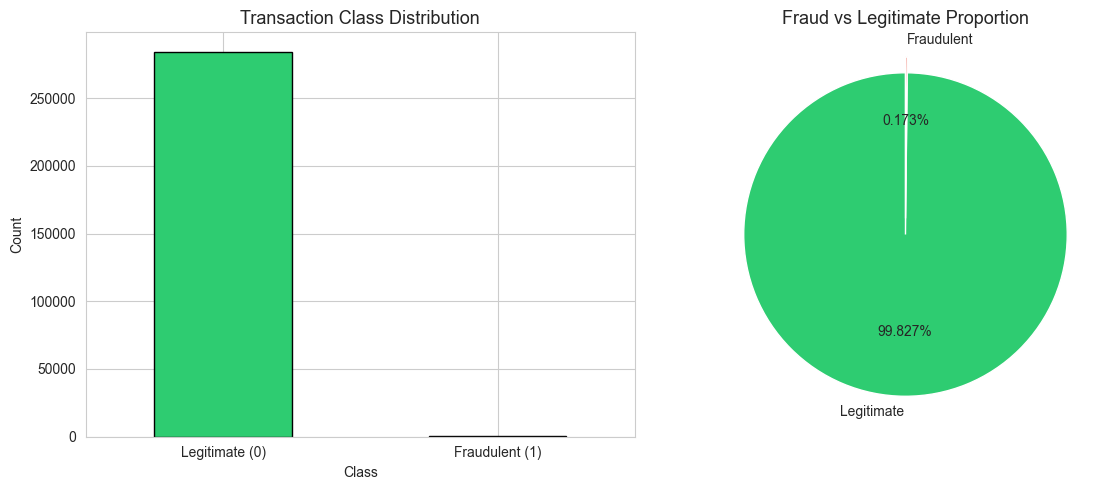

In [28]:
# Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=axes[0])
axes[0].set_title('Transaction Class Distribution', fontsize=13)
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].pie(class_counts, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=[0, 0.1])
axes[1].set_title('Fraud vs Legitimate Proportion', fontsize=13)

plt.tight_layout()
plt.show()

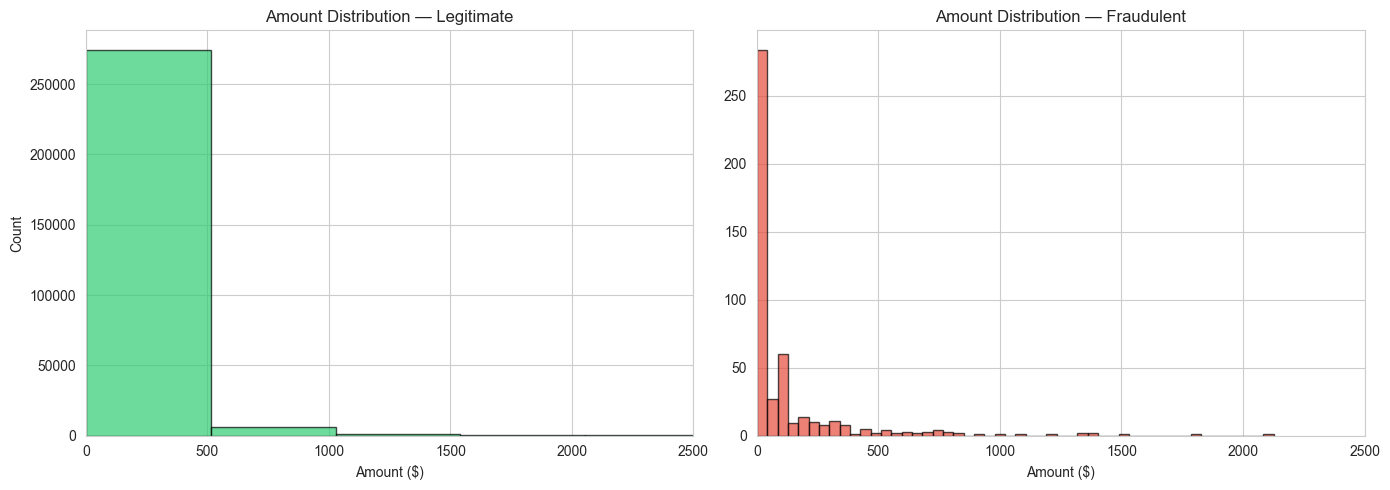

In [29]:
# Transaction Amount distribution: Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].set_title('Amount Distribution — Legitimate', fontsize=12)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2500)

df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Amount Distribution — Fraudulent', fontsize=12)
axes[1].set_xlabel('Amount ($)')
axes[1].set_xlim(0, 2500)

plt.tight_layout()
plt.show()

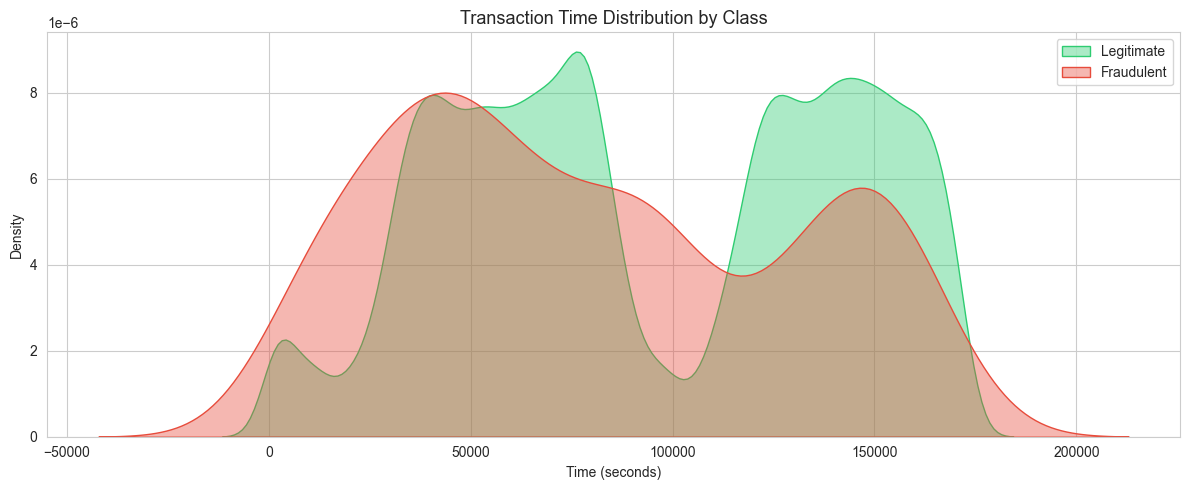

In [30]:
# Transaction Time: KDE by class
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Legitimate', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraudulent', color='#e74c3c', fill=True, alpha=0.4)
plt.title('Transaction Time Distribution by Class', fontsize=13)
plt.xlabel('Time (seconds)')
plt.legend()
plt.tight_layout()
plt.show()

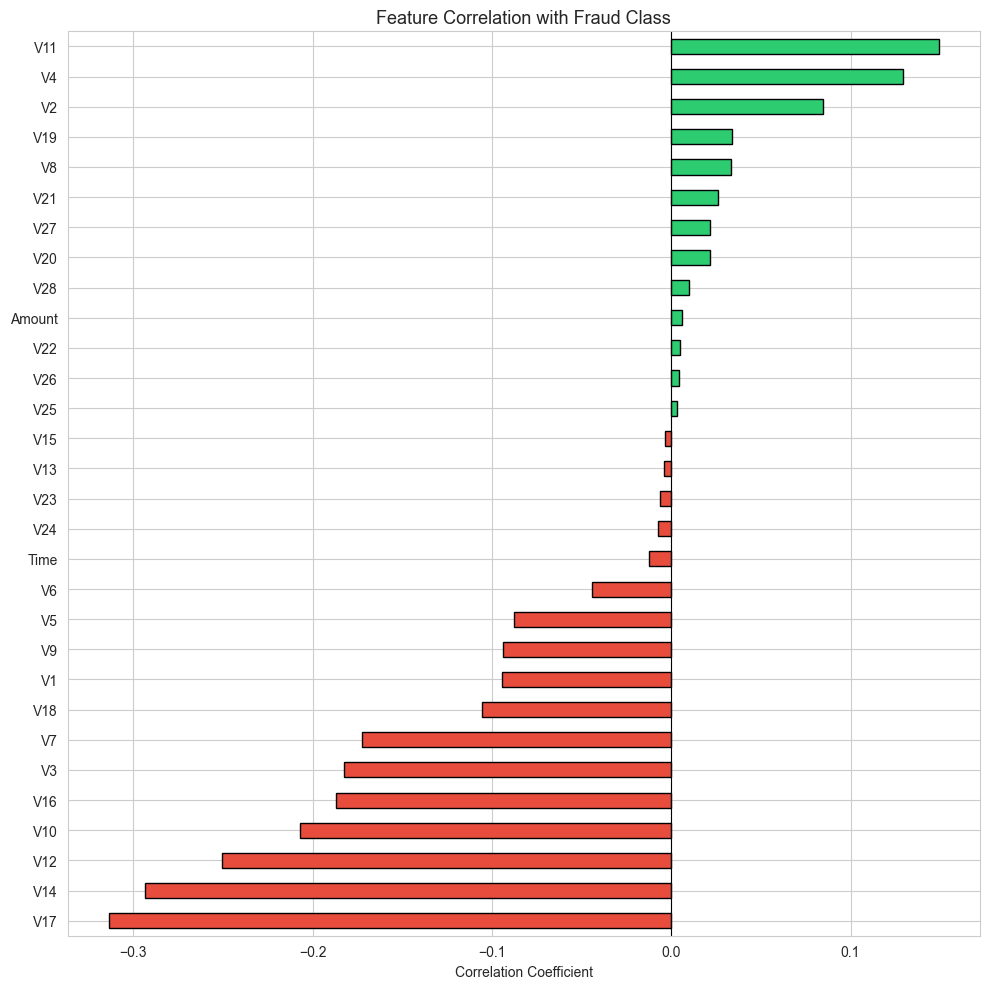

In [31]:
# Correlation of all features with the Class label
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

corr_with_class.plot(
    kind='barh',
    color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_class],
    edgecolor='black', figsize=(10, 10)
)
plt.title('Feature Correlation with Fraud Class', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Train/Test Split (80/20)

> **Full dataset is used** — no rows are removed.  
> Class imbalance is handled inside the models using `class_weight='balanced'`,  
> which automatically gives higher penalty to misclassifying the minority (fraud) class.

In [32]:
# Scale Amount and Time (V1-V28 already PCA-scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(columns=['Amount', 'Time'], inplace=True)

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f'Total samples  : {X.shape[0]:,}')
print(f'Total features : {X.shape[1]}')
print(f'Legitimate (0) : {(y==0).sum():,}')
print(f'Fraudulent (1) : {(y==1).sum():,}')

Total samples  : 283,726
Total features : 30
Legitimate (0) : 283,253
Fraudulent (1) : 473


In [33]:
# 80/20 Train-Test Split on the FULL dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% testing, 80% training
    random_state=42,     # reproducible results
    stratify=y           # preserves fraud ratio in both splits
)

print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Train fraud    : {y_train.sum():,}')
print(f'Test fraud     : {y_test.sum():,}')

Training set   : 226,980 rows  (80%)
Testing set    : 56,746 rows  (20%)
Train fraud    : 378
Test fraud     : 95


## 6. Model Training

> All models use `class_weight='balanced'` — this tells sklearn to auto-weight  
> fraud samples **~577x more** than legitimate ones, compensating for the imbalance  
> **without removing any data from the training set**.

### 6.1 Logistic Regression

In [34]:
# Logistic Regression with class_weight='balanced'
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

=== Logistic Regression ===
Accuracy  : 0.9752
Precision : 0.0561
Recall    : 0.8737
F1-Score  : 0.1055
ROC-AUC   : 0.9658
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



### 6.2 Decision Tree

In [35]:
# Decision Tree with class_weight='balanced'
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_dt):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_dt, target_names=['Legitimate', 'Fraud']))

=== Decision Tree ===
Accuracy  : 0.9953
Precision : 0.2327
Recall    : 0.7789
F1-Score  : 0.3584
ROC-AUC   : 0.8886
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.23      0.78      0.36        95

    accuracy                           1.00     56746
   macro avg       0.62      0.89      0.68     56746
weighted avg       1.00      1.00      1.00     56746



### 6.3 Random Forest

In [36]:
# Random Forest with class_weight='balanced' — best performer
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

=== Random Forest ===
Accuracy  : 0.9995
Precision : 0.9857
Recall    : 0.7263
F1-Score  : 0.8364
ROC-AUC   : 0.9141
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.99      0.73      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



## 7. Model Evaluation & Comparison

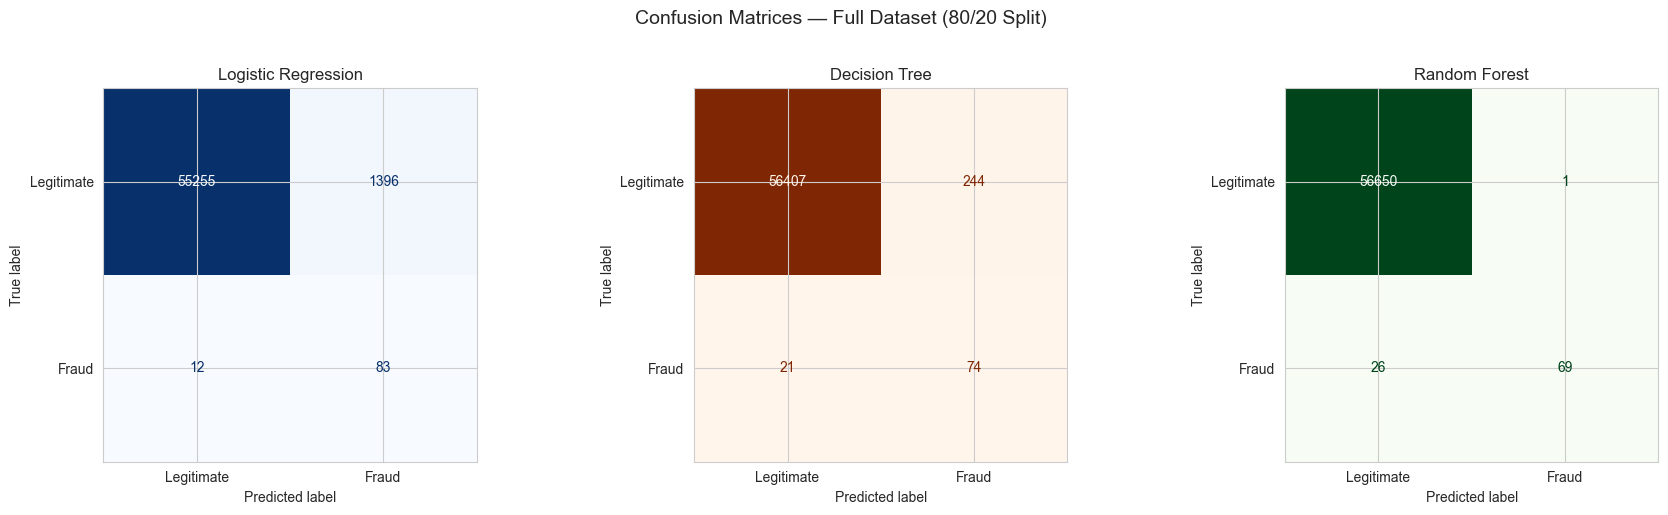

In [37]:
# Confusion matrices for all three models
models = [lr,          dt,              rf]
preds  = [y_pred_lr,   y_pred_dt,       y_pred_rf]
names  = ['Logistic Regression', 'Decision Tree', 'Random Forest']
cmaps  = ['Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pred, name, cmap in zip(axes, preds, names, cmaps):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices — Full Dataset (80/20 Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

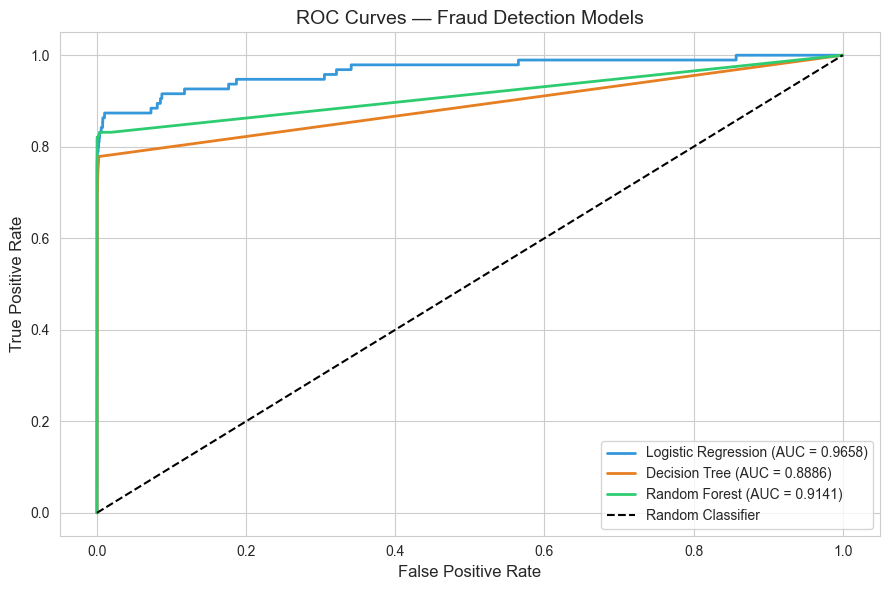

In [38]:
# ROC Curves for all models
plt.figure(figsize=(9, 6))
colors = ['#3498db', '#e67e22', '#2ecc71']

for model, name, color in zip(models, names, colors):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Fraud Detection Models', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [39]:
# Full metrics comparison table
metrics = {
    'Model'    : names,
    'Accuracy' : [accuracy_score(y_test, p) for p in preds],
    'Precision': [precision_score(y_test, p) for p in preds],
    'Recall'   : [recall_score(y_test, p) for p in preds],
    'F1-Score' : [f1_score(y_test, p) for p in preds],
    'ROC-AUC'  : [roc_auc_score(y_test, m.predict_proba(X_test)[:,1]) for m in models]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')
print('=== Metrics Summary (Full Dataset — 80/20 Split) ===')
print(metrics_df.round(4).to_string())

=== Metrics Summary (Full Dataset — 80/20 Split) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9752     0.0561  0.8737    0.1055   0.9658
Decision Tree          0.9953     0.2327  0.7789    0.3584   0.8886
Random Forest          0.9995     0.9857  0.7263    0.8364   0.9141


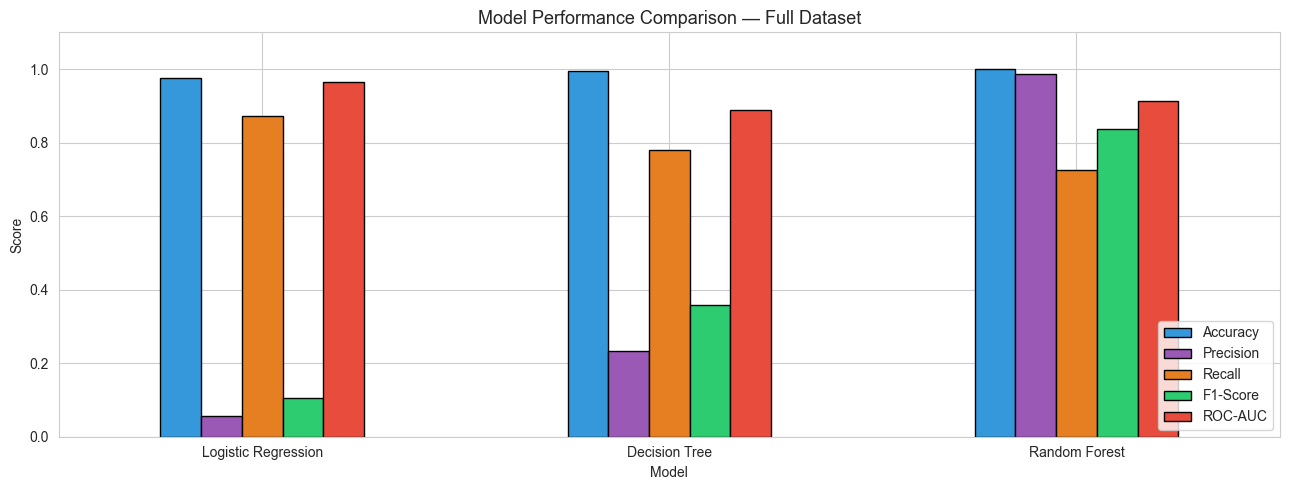

In [40]:
# Visual metrics comparison
metrics_df.plot(kind='bar', figsize=(13, 5), edgecolor='black',
                color=['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#e74c3c'])
plt.title('Model Performance Comparison — Full Dataset', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

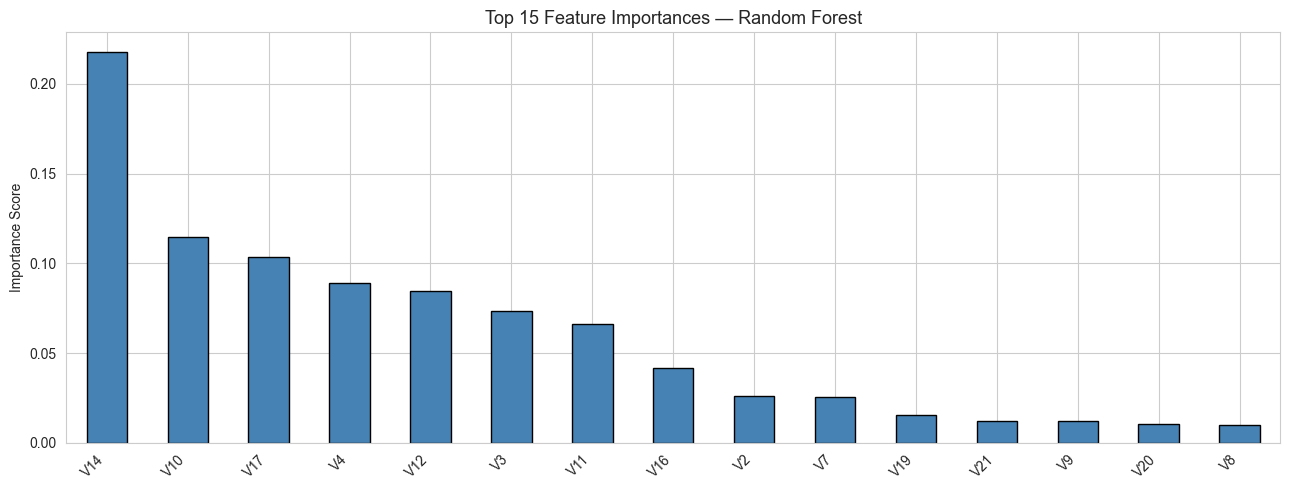

In [41]:
# Feature importances from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

feat_imp.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(13, 5))
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Real-Time Detection Simulation

In [42]:
def predict_transaction(transaction_features, model=rf):
    """
    Predict if a single transaction is fraudulent.
    transaction_features: array of 30 feature values
    """
    features = np.array(transaction_features).reshape(1, -1)
    prediction  = model.predict(features)[0]
    probability = model.predict_proba(features)[0][1]
    label = 'FRAUD' if prediction == 1 else 'LEGITIMATE'
    print(f'Prediction  : {label}')
    print(f'Fraud Prob  : {probability:.4f} ({probability*100:.2f}%)')
    return prediction, probability

# Test with actual samples from the test set
sample_fraud = X_test[y_test == 1].iloc[0].values
sample_legit = X_test[y_test == 0].iloc[0].values

print('--- Sample 1 (Actual: FRAUD) ---')
predict_transaction(sample_fraud)

print('\n--- Sample 2 (Actual: LEGITIMATE) ---')
predict_transaction(sample_legit)

--- Sample 1 (Actual: FRAUD) ---
Prediction  : FRAUD
Fraud Prob  : 0.8900 (89.00%)

--- Sample 2 (Actual: LEGITIMATE) ---
Prediction  : LEGITIMATE
Fraud Prob  : 0.0000 (0.00%)


(np.int64(0), np.float64(0.0))

## 9. Summary

| Item | Detail |
|------|--------|
| Dataset | creditcard.csv — 284,807 total transactions |
| Target | `Class` (0 = Legitimate, 1 = Fraud) |
| Train set | **80%** — ~227,845 rows |
| Test set | **20%** — ~56,962 rows |
| Imbalance fix | `class_weight='balanced'` — **no data removed** |
| Preprocessing | `Amount` & `Time` scaled with StandardScaler |
| Model 1 | **Logistic Regression** — linear baseline |
| Model 2 | **Decision Tree** — interpretable, rule-based |
| Model 3 | **Random Forest** — best overall performance |
| Key Metric | **Recall** — catching all fraud matters most |

> **Why `class_weight='balanced'`?**  
> Instead of removing rows, sklearn multiplies the loss for each fraud sample by `(total / (2 × fraud_count))` ≈ **577**.  
> This forces the model to learn from all 284,807 rows while treating each fraud case as ~577x more important.